In [1]:
%matplotlib inline
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()    # use seaborn plotting defaults
plt.rcParams["figure.figsize"] = (9, 6)    # set figure size for all plots 

## Example: Face Recognition

As an example of support vector machines (SVM) in action, let's take a look at the facial recognition problem.
We will use the [Labeled Faces in the Wild](https://scikit-learn.org/0.19/modules/generated/sklearn.datasets.fetch_lfw_people.html) dataset, which consists of several thousand collated photos of various public figures.
A fetcher for the dataset is built into Scikit-Learn:

In [2]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


Let's plot a few of these faces to see what we're working with:

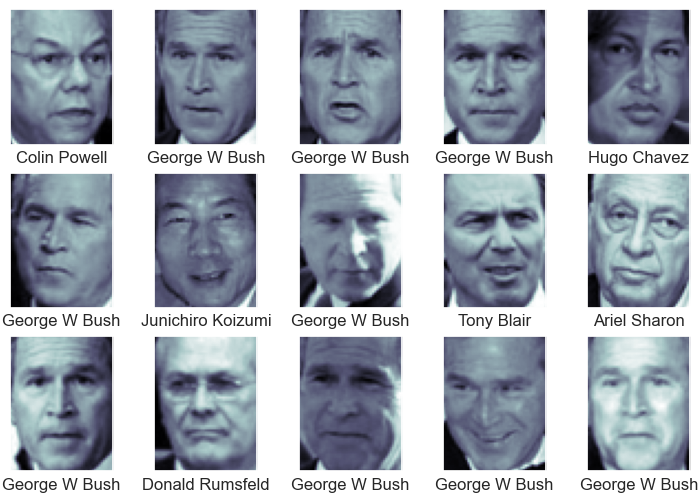

In [3]:
fig, ax = plt.subplots(3, 5)
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])

Do you remember how we used Naive Bayes in the first notebook without really explaining it? We will do this again here with a model called Support Vector Machine (SVM). It's not good practice to use Models that we don't understand but here SVM just works nicely. Also, thanks to the standardized interface that sklearn offers, it's pretty easy to do so. Finally, SVM is one of the models that "you should have heard about" even if it is just superficial. SVM is a pretty interesting model that used to play an important role in Data Science. However, due to unfortunate legal issues around it (you need to buy a license if you want to use it commercially) and the emergence of strong and easy-to-use alternatives it has lost significance. If you want to learn more about SVM, please contact us for some extra resources. For today's lesson, however, this is not necessary.

One of the shortcomings of SVM is that for large numbers of training samples, the computational cost of training an SVM can become problematic. That is why the combination of SVM + Dimensionality Reduction is powerful.


Each image contains [62×47] or nearly 3,000 pixels.
We could proceed by simply using each pixel value as a feature, but often it is more effective to use some sort of preprocessor to extract more meaningful features; here we will use a principal component analysis to extract 150 fundamental components to feed into our support vector machine classifier.
We can do this most straightforwardly by packaging the preprocessor and the classifier into a single pipeline:

In [5]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA as RandomizedPCA
from sklearn.pipeline import make_pipeline

pca = RandomizedPCA(n_components=150, whiten=True, random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

For the sake of testing our classifier output, we will split the data into a training and testing set:

In [6]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target,
                                                random_state=42)

Finally, we can use a grid search cross-validation to explore combinations of hyperparameters and determine the best model.

Two relevant hyperparameters for SVMs are ``C`` (which controls the margin hardness) and ``gamma`` (which controls the size of the radial basis function kernel).

In [7]:
from sklearn.model_selection import GridSearchCV
param_grid = {'svc__C': [5, 10, 50],
              'svc__gamma': [0.0005, 0.001, 0.005]}
grid = GridSearchCV(model, param_grid,verbose =5)

%time grid.fit(Xtrain, ytrain)
print(grid.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END .......svc__C=5, svc__gamma=0.0005;, score=0.783 total time=   0.3s
[CV 2/5] END .......svc__C=5, svc__gamma=0.0005;, score=0.842 total time=   0.2s
[CV 3/5] END .......svc__C=5, svc__gamma=0.0005;, score=0.827 total time=   0.2s
[CV 4/5] END .......svc__C=5, svc__gamma=0.0005;, score=0.817 total time=   0.2s
[CV 5/5] END .......svc__C=5, svc__gamma=0.0005;, score=0.861 total time=   0.2s
[CV 1/5] END ........svc__C=5, svc__gamma=0.001;, score=0.818 total time=   0.2s
[CV 2/5] END ........svc__C=5, svc__gamma=0.001;, score=0.842 total time=   0.2s
[CV 3/5] END ........svc__C=5, svc__gamma=0.001;, score=0.832 total time=   0.2s
[CV 4/5] END ........svc__C=5, svc__gamma=0.001;, score=0.817 total time=   0.2s
[CV 5/5] END ........svc__C=5, svc__gamma=0.001;, score=0.837 total time=   0.2s
[CV 1/5] END ........svc__C=5, svc__gamma=0.005;, score=0.818 total time=   0.2s
[CV 2/5] END ........svc__C=5, svc__gamma=0.005;,

The optimal values fall toward the middle of our grid; if they fell at the edges, we would want to expand the grid to make sure we have found the true optimum.

Now with this cross-validated model, we can predict the labels for the test data, which the model has not yet seen:

In [8]:
model = grid.best_estimator_
yfit = model.predict(Xtest)

Let's take a look at a few of the test images along with their predicted values:

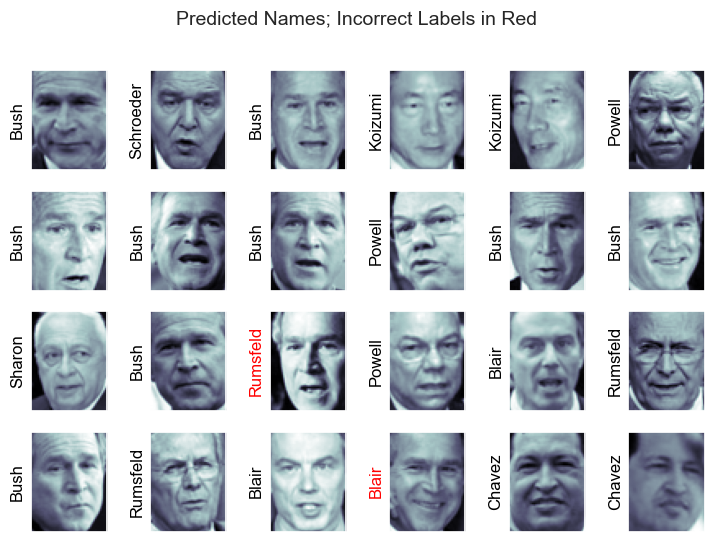

In [9]:
fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color='black' if yfit[i] == ytest[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14);

Out of this small sample, our optimal estimator mislabeled only a single face (Bush’s
face in the bottom row was mislabeled as Blair).
We can get a better sense of our estimator's performance using the classification report, which lists recovery statistics label by label:

In [10]:
from sklearn.metrics import classification_report
print(classification_report(ytest, yfit,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.87      0.74        15
     Colin Powell       0.83      0.88      0.86        68
  Donald Rumsfeld       0.70      0.84      0.76        31
    George W Bush       0.97      0.80      0.88       126
Gerhard Schroeder       0.76      0.83      0.79        23
      Hugo Chavez       0.93      0.70      0.80        20
Junichiro Koizumi       0.86      1.00      0.92        12
       Tony Blair       0.82      0.98      0.89        42

         accuracy                           0.85       337
        macro avg       0.82      0.86      0.83       337
     weighted avg       0.86      0.85      0.85       337



We might also display the confusion matrix between these classes:

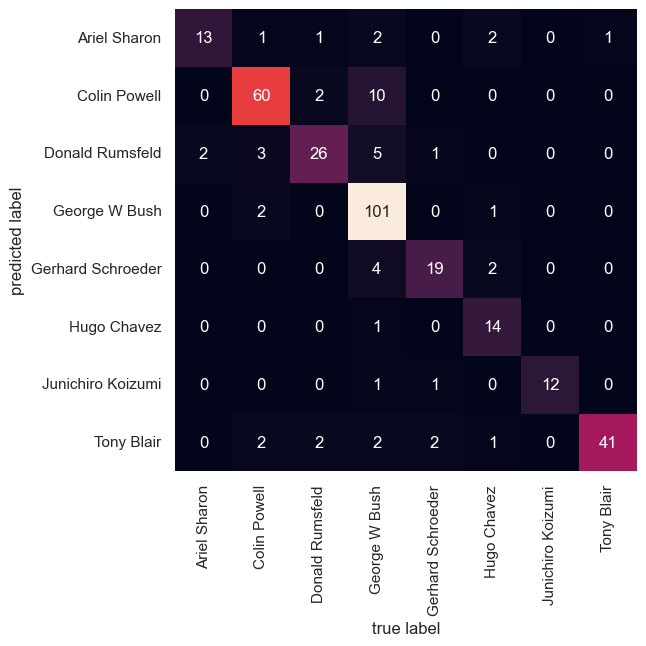

In [11]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

This helps us get a sense of which labels are likely to be confused by the estimator.

For a real-world facial recognition task, in which the photos do not come pre-cropped into nice grids, the only difference in the facial classification scheme is the feature selection: you would need to use a more sophisticated algorithm to find the faces, and extract features that are independent of the pixelation.
For this kind of application, one good option is to make use of [OpenCV](http://opencv.org), which, among other things, includes pre-trained implementations of state-of-the-art feature extraction tools for images in general and faces in particular.